<a href="https://colab.research.google.com/github/EshaSaha3/vanet_misbehavior_detection/blob/main/thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello, VANET thesis!")

Hello, VANET thesis!


In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6b93d662ed19cc2f9bf51d0fc7894fb2'

!pip install kaggle -q
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [ ]:
!kaggle datasets list -s "VeReMi"

ref                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
haider094/veremi-dataset                       VeReMi_dataset                                      3371592862  2023-07-13 19:00:43.940000           2579         18  0.47058824       
ivarprudnikov/veremi-extension-data-1-21-gb    VeReMi_Extension_Data_1_21_GB                        424879913  2024-12-02 21:39:43.210000            396          4  0.7058824        
shilpasayura/veremi-extension-simple           Veremi Extension Simple                              230588226  2024-08-31 21:31:33.987000            233          0  0.5882353        
chiragyshetty/balanced-veremi-dataset-csv      VeReMi dataset for Malicious Vehicle I

In [ ]:
!kaggle datasets download -d ivarprudnikov/veremi-extension-data-1-21-gb -p /content/veremi_data --unzip

Dataset URL: https://www.kaggle.com/datasets/ivarprudnikov/veremi-extension-data-1-21-gb
License(s): CC-BY-SA-4.0
100% 405M/405M [00:20<00:00, 20.6MB/s]



In [ ]:
import os

for root, dirs, files in os.walk('/content/veremi_data'):
    level = root.replace('/content/veremi_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # প্রথম ৫টা ফাইল দেখাবে প্রতি ফোল্ডারে
        print(f'{subindent}{file}')
    if len(files) > 5:
        print(f'{subindent}... আরও {len(files)-5} টা ফাইল')

veremi_data/
  mixalldata_clean.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/veremi_data/mixalldata_clean.csv')

print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nপ্রথম ৫টা row:")
df.head()

Shape (rows, columns): (3194808, 30)

Column names:
['type', 'sendTime', 'sender', 'senderPseudo', 'messageID', 'class', 'posx', 'posy', 'posz', 'posx_n', 'posy_n', 'posz_n', 'spdx', 'spdy', 'spdz', 'spdx_n', 'spdy_n', 'spdz_n', 'aclx', 'acly', 'aclz', 'aclx_n', 'acly_n', 'aclz_n', 'hedx', 'hedy', 'hedz', 'hedx_n', 'hedy_n', 'hedz_n']

প্রথম ৫টা row:


,type,sendTime,sender,senderPseudo,messageID,class,posx,posy,posz,posx_n,...,aclz,aclx_n,acly_n,aclz_n,hedx,hedy,hedz,hedx_n,hedy_n,hedz_n
0,4,72002.302942,130137,101301377,422013806,0,266.982401,32.336955,0.0,3.480882,...,0.0,0.000862,0.000862,0.0,-0.102790,0.994703,0.0,20.038218,17.541001,0.0
1,4,72003.302942,130137,101301377,422023410,0,266.827208,34.624145,0.0,3.546261,...,0.0,0.000107,0.001040,0.0,-0.099856,0.995002,0.0,20.441139,14.467283,0.0
2,4,72004.302942,130137,101301377,422032081,0,266.420297,38.836461,0.0,3.544045,...,0.0,0.000172,0.001661,0.0,-0.099856,0.995002,0.0,20.850473,11.941528,0.0
3,4,72005.302942,130137,101301377,422040712,0,268.912026,45.414229,0.0,3.340080,...,0.0,0.000171,0.001654,0.0,-0.100172,0.994970,0.0,21.323229,9.633965,0.0
4,4,72006.302942,130137,101301377,422052949,0,268.242276,53.729986,0.0,3.328872,...,0.0,0.000193,0.001852,0.0,-0.097105,0.995274,0.0,21.788034,7.824555,0.0


In [ ]:
print("Class column-এর unique values ও count:")
print(df['class'].value_counts())

Class column-এর unique values ও count:
class
0     1900539
16     175391
13     131305
15     129270
14     126724
18      86883
19      82100
6       44359
11      44337
17      44310
3       43857
1       43653
2       43567
10      43264
12      43118
9       42790
8       42583
4       42575
7       42258
5       41925
Name: count, dtype: int64


In [ ]:
print("Missing values প্রতি column-এ:")
print(df.isnull().sum())

print("\nsenderPseudo-এর unique count (কতগুলো ভিন্ন vehicle আছে):")
print(df['senderPseudo'].nunique())

Missing values প্রতি column-এ:
type            0
sendTime        0
sender          0
senderPseudo    0
messageID       0
class           0
posx            0
posy            0
posz            0
posx_n          0
posy_n          0
posz_n          0
spdx            0
spdy            0
spdz            0
spdx_n          0
spdy_n          0
spdz_n          0
aclx            0
acly            0
aclz            0
aclx_n          0
acly_n          0
aclz_n          0
hedx            0
hedy            0
hedz            0
hedx_n          0
hedy_n          0
hedz_n          0
dtype: int64

senderPseudo-এর unique count (কতগুলো ভিন্ন vehicle আছে):
118909


In [ ]:
# প্রতিটা vehicle কয়টা ভিন্ন class দেখাচ্ছে চেক করি
vehicle_class_counts = df.groupby('senderPseudo')['class'].nunique()
print("প্রতি vehicle কতগুলো ভিন্ন class-এ পড়ে (distribution):")
print(vehicle_class_counts.value_counts())

প্রতি vehicle কতগুলো ভিন্ন class-এ পড়ে (distribution):
class
1    118909
Name: count, dtype: int64


In [ ]:
# প্রতিটা attack class-এ কতগুলো ভিন্ন vehicle আছে
vehicles_per_class = df.groupby('class')['senderPseudo'].nunique()
print("প্রতি class-এ কতগুলো ভিন্ন vehicle:")
print(vehicles_per_class)

প্রতি class-এ কতগুলো ভিন্ন vehicle:
class
0     17264
1       390
2       390
3       390
4       389
5       390
6       389
7       389
8       389
9       389
10      390
11      389
12      390
13      390
14      389
15      389
16     1564
17    22259
18    36106
19    35874
Name: senderPseudo, dtype: int64


In [ ]:
# real sender (আসল গাড়ি) vs senderPseudo (দেখানো পরিচয়) তুলনা করি
comparison = df.groupby('class').agg(
    real_vehicles=('sender', 'nunique'),
    pseudo_identities=('senderPseudo', 'nunique')
)
comparison['ratio'] = comparison['pseudo_identities'] / comparison['real_vehicles']
print(comparison)

       real_vehicles  pseudo_identities      ratio
class                                             
0              17264              17264   1.000000
1                390                390   1.000000
2                390                390   1.000000
3                390                390   1.000000
4                389                389   1.000000
5                390                390   1.000000
6                389                389   1.000000
7                389                389   1.000000
8                389                389   1.000000
9                389                389   1.000000
10               390                390   1.000000
11               389                389   1.000000
12               390                390   1.000000
13               390                390   1.000000
14               389                389   1.000000
15               389                389   1.000000
16               389               1564   4.020566
17               389           

In [ ]:
import matplotlib.pyplot as plt

comparison_reset = comparison.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(comparison_reset['class'].astype(str), comparison_reset['ratio'], color='steelblue')
plt.xlabel('Class (Attack Type)')
plt.ylabel('Pseudo Identity / Real Vehicle Ratio')
plt.title('Sybil Attack Intensity by Class (VeReMi Extension Dataset)')
plt.axhline(y=1, color='red', linestyle='--', label='Normal ratio (1.0)')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/sybil_ratio_plot.png', dpi=150)
plt.show()

NameError: name 'comparison' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# dataset আবার load করি (যদি আগেরটা মুছে গিয়ে থাকে)
df = pd.read_csv('/content/veremi_data/mixalldata_clean.csv')

# comparison আবার বানাই
comparison = df.groupby('class').agg(
    real_vehicles=('sender', 'nunique'),
    pseudo_identities=('senderPseudo', 'nunique')
)
comparison['ratio'] = comparison['pseudo_identities'] / comparison['real_vehicles']

# এখন graph বানাই
comparison_reset = comparison.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(comparison_reset['class'].astype(str), comparison_reset['ratio'], color='steelblue')
plt.xlabel('Class (Attack Type)')
plt.ylabel('Pseudo Identity / Real Vehicle Ratio')
plt.title('Sybil Attack Intensity by Class (VeReMi Extension Dataset)')
plt.axhline(y=1, color='red', linestyle='--', label='Normal ratio (1.0)')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/sybil_ratio_plot.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/veremi_data/mixalldata_clean.csv'

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6b93d662ed19cc2f9bf51d0fc7894fb2'

!pip install kaggle -q
!kaggle datasets download -d ivarprudnikov/veremi-extension-data-1-21-gb -p /content/veremi_data --unzip

Dataset URL: https://www.kaggle.com/datasets/ivarprudnikov/veremi-extension-data-1-21-gb
License(s): CC-BY-SA-4.0
100% 405M/405M [00:20<00:00, 20.7MB/s]



Dataset loaded, shape: (3194808, 30)


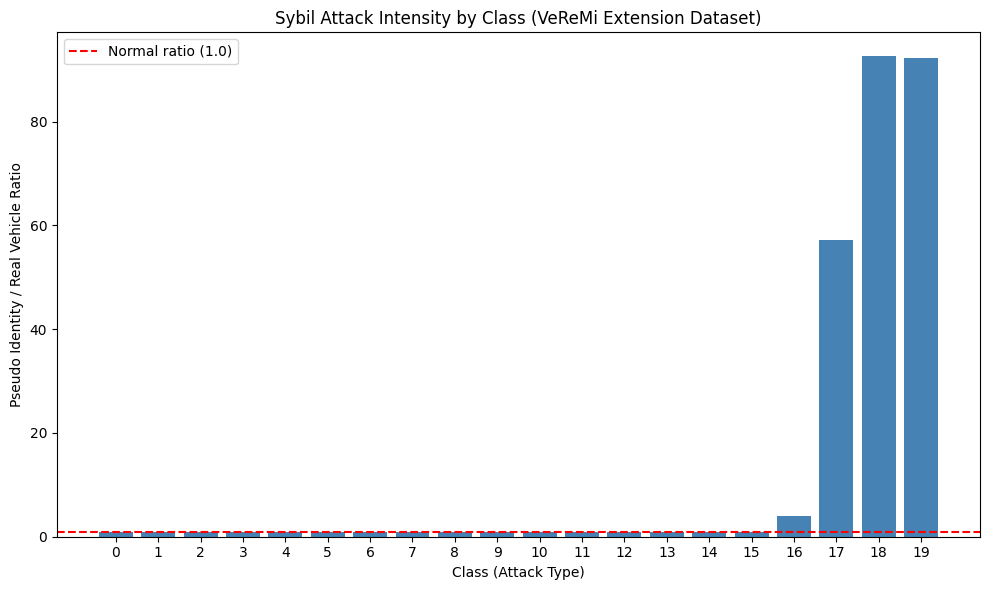

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# dataset load
df = pd.read_csv('/content/veremi_data/mixalldata_clean.csv')
print("Dataset loaded, shape:", df.shape)

# comparison বানাই
comparison = df.groupby('class').agg(
    real_vehicles=('sender', 'nunique'),
    pseudo_identities=('senderPseudo', 'nunique')
)
comparison['ratio'] = comparison['pseudo_identities'] / comparison['real_vehicles']

# graph বানাই
comparison_reset = comparison.reset_index()

plt.figure(figsize=(10, 6))
plt.bar(comparison_reset['class'].astype(str), comparison_reset['ratio'], color='steelblue')
plt.xlabel('Class (Attack Type)')
plt.ylabel('Pseudo Identity / Real Vehicle Ratio')
plt.title('Sybil Attack Intensity by Class (VeReMi Extension Dataset)')
plt.axhline(y=1, color='red', linestyle='--', label='Normal ratio (1.0)')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/sybil_ratio_plot.png', dpi=150)
plt.show()

In [ ]:
# প্রথমে sender ও sendTime অনুযায়ী sort করি (time-series ধারাবাহিকতা বজায় রাখতে)
df = df.sort_values(by=['senderPseudo', 'sendTime']).reset_index(drop=True)

# প্রতিটা vehicle-এর জন্য আলাদা করে acceleration-এর time-difference বের করি (jerk)
df['jerkx'] = df.groupby('senderPseudo')['aclx'].diff()
df['jerky'] = df.groupby('senderPseudo')['acly'].diff()
df['jerkz'] = df.groupby('senderPseudo')['aclz'].diff()

# প্রথম record-এ jerk পাওয়া যাবে না (কোনো আগের acceleration নেই), তাই NaN হবে
print("Jerk column-এ missing value:")
print(df[['jerkx', 'jerky', 'jerkz']].isnull().sum())

print("\nনমুনা দেখি:")
df[['senderPseudo', 'sendTime', 'aclx', 'jerkx']].head(10)

Jerk column-এ missing value:
jerkx    118909
jerky    118909
jerkz    118909
dtype: int64

নমুনা দেখি:


,senderPseudo,sendTime,aclx,jerkx
0,1,16281.126670,-0.206743,NaN
1,1,16281.460004,-0.206743,0.000000
2,1,16281.626670,-0.206743,0.000000
3,1,16281.793337,-0.206743,0.000000
4,1,16281.960004,-0.206743,0.000000
5,1,16282.126670,-0.161765,0.044978
6,1,16282.460004,-0.161765,0.000000
7,1,16282.626670,-0.161765,0.000000
8,1,16282.793337,-0.161765,0.000000
9,1,16282.960004,-0.161765,0.000000


In [ ]:
df['jerkx'] = df['jerkx'].fillna(0)
df['jerky'] = df['jerky'].fillna(0)
df['jerkz'] = df['jerkz'].fillna(0)

print("Fill করার পর missing value:")
print(df[['jerkx', 'jerky', 'jerkz']].isnull().sum())

print("\nJerk-এর basic statistics:")
print(df[['jerkx', 'jerky', 'jerkz']].describe())

Fill করার পর missing value:
jerkx    0
jerky    0
jerkz    0
dtype: int64

Jerk-এর basic statistics:
              jerkx         jerky      jerkz
count  3.194808e+06  3.194808e+06  3194808.0
mean   1.937129e-03 -3.433090e-04        0.0
std    9.710016e-01  1.043045e+00        0.0
min   -8.858298e+00 -8.955617e+00        0.0
25%   -2.271925e-01 -2.685894e-01        0.0
50%    0.000000e+00  0.000000e+00        0.0
75%    2.344532e-01  2.668827e-01        0.0
max    8.790765e+00  8.963918e+00        0.0


Normal traffic (class 0) - jerkx statistics:
count    1.900539e+06
mean     1.221875e-03
std      9.787390e-01
min     -7.455814e+00
25%     -2.499622e-01
50%      0.000000e+00
75%      2.581082e-01
max      7.476048e+00
Name: jerkx, dtype: float64

Sybil attack (class 18) - jerkx statistics:
count    86883.000000
mean        -0.000443
std          0.625632
min         -1.989097
25%         -0.154594
50%          0.000000
75%          0.145566
max          1.994929
Name: jerkx, dtype: float64


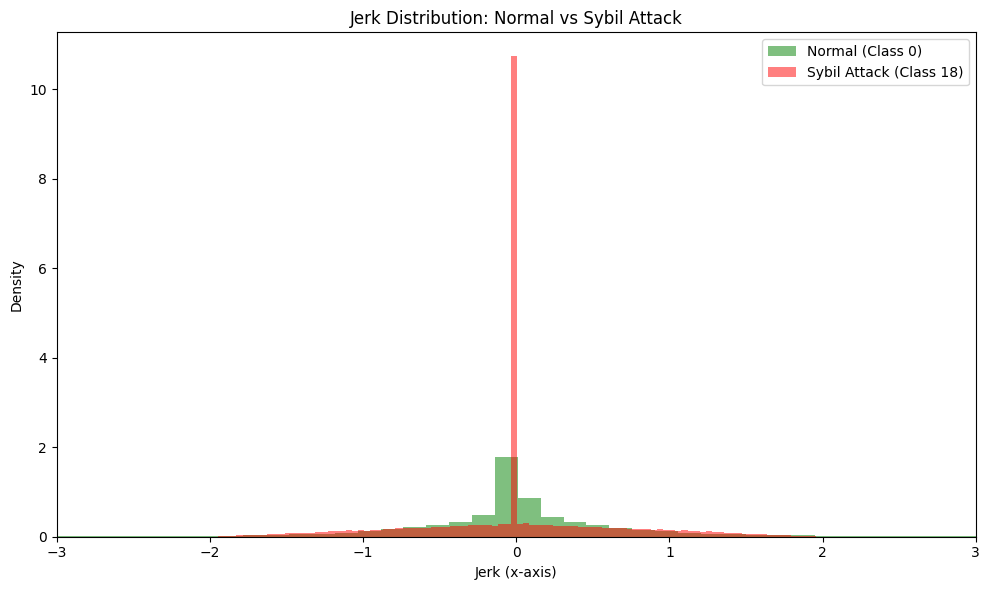

In [ ]:
# শুধু class 0 (normal) এবং class 18 (সবচেয়ে তীব্র Sybil) তুলনা করি
normal_jerk = df[df['class'] == 0]['jerkx']
sybil_jerk = df[df['class'] == 18]['jerkx']

print("Normal traffic (class 0) - jerkx statistics:")
print(normal_jerk.describe())

print("\nSybil attack (class 18) - jerkx statistics:")
print(sybil_jerk.describe())

# Visualization
plt.figure(figsize=(10, 6))
plt.hist(normal_jerk, bins=100, alpha=0.5, label='Normal (Class 0)', color='green', density=True)
plt.hist(sybil_jerk, bins=100, alpha=0.5, label='Sybil Attack (Class 18)', color='red', density=True)
plt.xlabel('Jerk (x-axis)')
plt.ylabel('Density')
plt.title('Jerk Distribution: Normal vs Sybil Attack')
plt.legend()
plt.xlim(-3, 3)  # বেশিরভাগ data এই range-এ, ভালো দেখার জন্য
plt.tight_layout()
plt.savefig('/content/jerk_comparison_plot.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/veremi_data/mixalldata_clean.csv')
print("Dataset shape:", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/veremi_data/mixalldata_clean.csv'

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6b93d662ed19cc2f9bf51d0fc7894fb2'

!pip install kaggle -q
!kaggle datasets download -d ivarprudnikov/veremi-extension-data-1-21-gb -p /content/veremi_data --unzip

Dataset URL: https://www.kaggle.com/datasets/ivarprudnikov/veremi-extension-data-1-21-gb
License(s): CC-BY-SA-4.0
100% 405M/405M [00:05<00:00, 84.7MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import pandas as pd

df = pd.read_csv('/content/veremi_data/mixalldata_clean.csv')
print("Dataset loaded, shape:", df.shape)

Dataset loaded, shape: (3194808, 30)


In [ ]:
# sender ও sendTime অনুযায়ী sort করি (time-series ধারাবাহিকতার জন্য)
df = df.sort_values(by=['senderPseudo', 'sendTime']).reset_index(drop=True)

# jerk feature বানাই (acceleration-এর time-derivative)
df['jerkx'] = df.groupby('senderPseudo')['aclx'].diff()
df['jerky'] = df.groupby('senderPseudo')['acly'].diff()
df['jerkz'] = df.groupby('senderPseudo')['aclz'].diff()

# প্রতিটা vehicle-এর প্রথম record-এর NaN 0 দিয়ে fill করি
df['jerkx'] = df['jerkx'].fillna(0)
df['jerky'] = df['jerky'].fillna(0)
df['jerkz'] = df['jerkz'].fillna(0)

print("Jerk feature তৈরি সম্পন্ন")
print(df[['senderPseudo', 'sendTime', 'aclx', 'jerkx']].head(10))

Jerk feature তৈরি সম্পন্ন
   senderPseudo      sendTime      aclx     jerkx
0             1  16281.126670 -0.206743  0.000000
1             1  16281.460004 -0.206743  0.000000
2             1  16281.626670 -0.206743  0.000000
3             1  16281.793337 -0.206743  0.000000
4             1  16281.960004 -0.206743  0.000000
5             1  16282.126670 -0.161765  0.044978
6             1  16282.460004 -0.161765  0.000000
7             1  16282.626670 -0.161765  0.000000
8             1  16282.793337 -0.161765  0.000000
9             1  16282.960004 -0.161765  0.000000


Normal traffic (class 0) - jerkx statistics:
count    1.900539e+06
mean     1.221875e-03
std      9.787390e-01
min     -7.455814e+00
25%     -2.499622e-01
50%      0.000000e+00
75%      2.581082e-01
max      7.476048e+00
Name: jerkx, dtype: float64

Sybil attack (class 18) - jerkx statistics:
count    86883.000000
mean        -0.000443
std          0.625632
min         -1.989097
25%         -0.154594
50%          0.000000
75%          0.145566
max          1.994929
Name: jerkx, dtype: float64


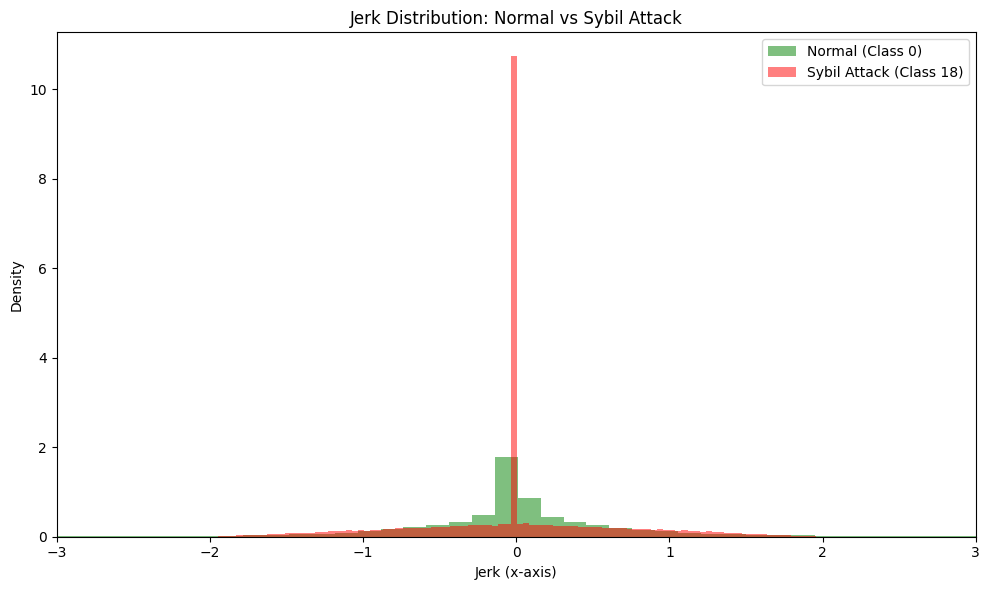

In [ ]:
import matplotlib.pyplot as plt

# normal (class 0) এবং সবচেয়ে তীব্র Sybil attack (class 18) তুলনা করি
normal_jerk = df[df['class'] == 0]['jerkx']
sybil_jerk = df[df['class'] == 18]['jerkx']

print("Normal traffic (class 0) - jerkx statistics:")
print(normal_jerk.describe())

print("\nSybil attack (class 18) - jerkx statistics:")
print(sybil_jerk.describe())

# Visualization
plt.figure(figsize=(10, 6))
plt.hist(normal_jerk, bins=100, alpha=0.5, label='Normal (Class 0)', color='green', density=True)
plt.hist(sybil_jerk, bins=100, alpha=0.5, label='Sybil Attack (Class 18)', color='red', density=True)
plt.xlabel('Jerk (x-axis)')
plt.ylabel('Density')
plt.title('Jerk Distribution: Normal vs Sybil Attack')
plt.legend()
plt.xlim(-3, 3)
plt.tight_layout()
plt.savefig('/content/jerk_comparison_plot.png', dpi=150)
plt.show()